<center><h1>Soundalgekar_Abhishek_HW3</h1></center>
<br>
<br>

### Name: Abhishek Soundalgekar ###
### Github Username: ABHISHEKSOUNDALGEKAR ###
### USC ID: 2089011000 ### 

- - -

## 1. Time Series Classification Part 1: Feature Creation/Extraction

### (a) Download Data

Package imports

In [1]:
pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from collections import defaultdict
import bootstrapped.bootstrap as bs
import bootstrapped.stats_functions as bs_stats
import seaborn as sns
import warnings
import glob
import statsmodels.api as sm
warnings.filterwarnings('ignore')
from pathlib import Path
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

---

### 1] (b) Keep datasets 1 and 2 in folders bending1 and bending 2, as well as datasets 1, 2, and 3 in other folders as test data and other datasets as train data

In [3]:
def read_csv_flexible(path: Path, skiprows: int = 4) -> pd.DataFrame:
    return pd.read_csv(
        path,
        skiprows=skiprows,
        engine="python",
        on_bad_lines="skip"
    )

def load_indices(folder: Path) -> list[int]:
    return sorted(
        int(p.stem.replace("dataset", ""))
        for p in folder.glob("dataset*.csv")
    )

def report_bad_rows(root_dir: str = ".", data_subdir: str = "data/ARem"):
    def count_rows(path: Path, skiprows: int = 4):
        with open(path, "r", encoding="utf-8") as f:
            lines = [line for line in f if line.strip()]
        total_data_rows = len(lines) - skiprows - 1
        actual_df = pd.read_csv(
            path,
            skiprows=skiprows,
            engine="python",
            on_bad_lines="skip"
        )
        return total_data_rows, len(actual_df)

    root = Path(root_dir) / data_subdir
    mismatches = []
    for folder in root.iterdir():
        if not folder.is_dir():
            continue
        for csv in folder.glob("dataset*.csv"):
            expected, actual = count_rows(csv)
            if expected != actual:
                mismatches.append((csv, expected, actual))

    if mismatches:
        print("Files with row mismatches:")
        for fn, exp, act in mismatches:
            print(f"  • {fn}: expected {exp} rows but read {act}")
    else:
        print("All files have consistent row counts.")

def prepare_ar_em(root_dir: str = ".", data_subdir: str = "data/ARem"):
    root = Path(root_dir) / data_subdir

    special = {"bending1": [1, 2], "bending2": [1, 2]}
    default_test = [1, 2, 3]

    train_parts, test_parts = [], []

    for folder in root.iterdir():
        if not folder.is_dir():
            continue
        activity = folder.name
        all_idxs = load_indices(folder)

        test_idxs  = special.get(activity, default_test)
        train_idxs = [i for i in all_idxs if i not in test_idxs]

        df_test = pd.concat(
            (read_csv_flexible(folder / f"dataset{i}.csv") for i in test_idxs),
            ignore_index=True
        )
        df_test["activity"] = activity

        df_train = pd.concat(
            (read_csv_flexible(folder / f"dataset{i}.csv") for i in train_idxs),
            ignore_index=True
        )
        df_train["activity"] = activity

        test_parts.append(df_test)
        train_parts.append(df_train)

    train_df = pd.concat(train_parts, ignore_index=True)
    test_df  = pd.concat(test_parts,  ignore_index=True)
    return train_df, test_df

if __name__ == "__main__":
    report_bad_rows(root_dir="..")
    train_df, test_df = prepare_ar_em(root_dir="..")
    train_df = train_df.drop(columns="activity")
    test_df  = test_df.drop(columns="activity")
    print(f"Train shape: {train_df.shape}")
    print(f"Test  shape: {test_df.shape}")

Files with row mismatches:
  • ../data/ARem/cycling/dataset14.csv: expected 480 rows but read 479
  • ../data/ARem/cycling/dataset9.csv: expected 480 rows but read 479
Train shape: (33117, 7)
Test  shape: (9120, 7)


### 1] (c) Feature Extraction

#### 1] (c) (i) Research what types of time-domain features are usually used in time series classification and list them

* **Central Tendency & Quantiles**: Mean and median provide average and central values, while quantiles (e.g., 25th, 75th percentiles) capture distribution thresholds.

* **Range & Dispersion**: Minimum, maximum, and range (max–min) indicate signal extremes; standard deviation and variance measure overall spread, with coefficient of variation normalizing by mean.

* **Distribution Shape**: Skewness quantifies asymmetry around the mean, and kurtosis reflects tail heaviness.

* **Temporal Dynamics**: Autocorrelation at lagged intervals reveals repetitive patterns or memory, while zero-crossing rate counts sign changes indicating oscillation.

* **Peak-Related Measures**: Peak-to-peak amplitude measures maximum excursion between peaks and troughs; peak counts track local maxima frequency.

* **Stationarity & Complexity**: The Augmented Dickey–Fuller (ADF) test assesses series stationarity, while entropy metrics like sample entropy quantify signal irregularity.


#### 1] (c) (ii) Extract the time-domain features minimum, maximum, mean, median, standard deviation, first quartile, and third quartile for all of the 6 time series in each instance. You are free to normalize/standardize features or use them directly

In [4]:
def read_csv_flexible(path: Path, skiprows: int = 4) -> pd.DataFrame:
    return pd.read_csv(
        path,
        skiprows=skiprows,
        engine="python",
        on_bad_lines="skip"
    )

def extract_time_features(folder: Path,
                          activity: str,
                          start_instance: int,
                          series_cols: list[str]) -> tuple[list[list], int]:
    if activity == "bending1":
        num_files = 7
    elif activity == "bending2":
        num_files = 6
    else:
        num_files = 15

    data_rows = []
    for i in range(1, num_files + 1):
        file_path = folder / f"dataset{i}.csv"
        df = read_csv_flexible(file_path)

        features_df = [start_instance]
        for j, col in enumerate(series_cols):
            col_data = df[col]
            features_df.append(col_data.min())
            features_df.append(col_data.max())
            features_df.append(col_data.mean())
            features_df.append(col_data.median())
            features_df.append(col_data.std())
            features_df.append(col_data.quantile(0.25))
            features_df.append(col_data.quantile(0.75))
        data_rows.append(features_df)
        start_instance += 1

    return data_rows, start_instance

if __name__ == "__main__":
    data_root = Path("..") / "data" / "ARem"
    series = ["avg_rss12", "var_rss12",
              "avg_rss13", "var_rss13",
              "avg_rss23", "var_rss23"]

    all_data = []
    instance_id = 1

    for activity_folder in sorted(data_root.iterdir()):
        if activity_folder.is_dir():
            activity = activity_folder.name
            extracted_rows, instance_id = extract_time_features(
                activity_folder, activity, instance_id, series
            )
            all_data.extend(extracted_rows)

    # Create custom column headers like min1, max1, ..., 3rd_quart6
    stats = ["min", "max", "mean", "median", "std", "1st_quart", "3rd_quart"]
    headers = ["instance"]
    for i in range(6):
        for stat in stats:
            headers.append(f"{stat}{i+1}")

    df = pd.DataFrame(all_data, columns=headers)

    output_csv = data_root / "time_series_features.csv"
    df.to_csv(output_csv, index=False)

    print(f" New Dataset at: {output_csv}")
    print(df.head(5))

    # Open the CSV file using the default app
    try:
        os.startfile(output_csv)  # Windows
    except AttributeError:
        os.system(f"open {output_csv}")  # macOS/Linux


 New Dataset at: ../data/ARem/time_series_features.csv
   instance   min1   max1      mean1  median1      std1  1st_quart1  \
0         1  37.25  45.00  40.624792    40.50  1.476967       39.25   
1         2  38.00  45.67  42.812812    42.50  1.435550       42.00   
2         3  35.00  47.40  43.954500    44.33  1.558835       43.00   
3         4  33.00  47.75  42.179812    43.50  3.670666       39.15   
4         5  33.00  45.75  41.678063    41.75  2.243490       41.33   

   3rd_quart1  min2  max2  ...      std5  1st_quart5  3rd_quart5  min6  max6  \
0       42.00   0.0  1.30  ...  2.188449     33.0000       36.00   0.0  1.92   
1       43.67   0.0  1.22  ...  1.995255     32.0000       34.50   0.0  3.11   
2       45.00   0.0  1.70  ...  1.999604     35.3625       36.50   0.0  1.79   
3       45.00   0.0  3.00  ...  3.849448     30.4575       36.33   0.0  2.18   
4       42.75   0.0  2.83  ...  2.411026     28.4575       31.25   0.0  1.79   

      mean6  median6      std6  1st_q

### 1] C] (iii) Estimate the standard deviation of each of the time-domain features you extracted from the data. Then, use Python’s bootstrapped or any other method to build a 90% bootsrap confidence interval for the standard deviation of each feature.


Standard Deviations and 90% Bootstrap CIs:

            Std Dev  CI Lower  CI Upper
min1         9.6240    8.3409   10.8282
max1         4.2077    3.1465    5.1449
mean1        5.2764    4.6439    5.8444
median1      5.3866    4.7270    5.9617
std1         1.7713    1.5673    1.9524
1st_quart1   6.1281    5.5304    6.6350
3rd_quart1   5.0310    4.2135    5.7583
min2         0.0000    0.0000    0.0000
max2         5.0597    4.6206    5.3948
mean2        1.5779    1.3978    1.7106
median2      1.4136    1.2383    1.5452
std2         0.8859    0.8031    0.9441
1st_quart2   0.9484    0.8320    1.0386
3rd_quart2   2.1315    1.8964    2.3003
min3         2.9545    2.7546    3.1069
max3         4.8198    4.0852    5.4316
mean3        3.9766    3.3585    4.4725
median3      4.0097    3.3779    4.5222
std3         0.9520    0.7682    1.1309
1st_quart3   4.1841    3.5622    4.6791
3rd_quart3   4.1535    3.4987    4.6790
min4         0.0000    0.0000    0.0000
max4         2.1818    1.9731    2.

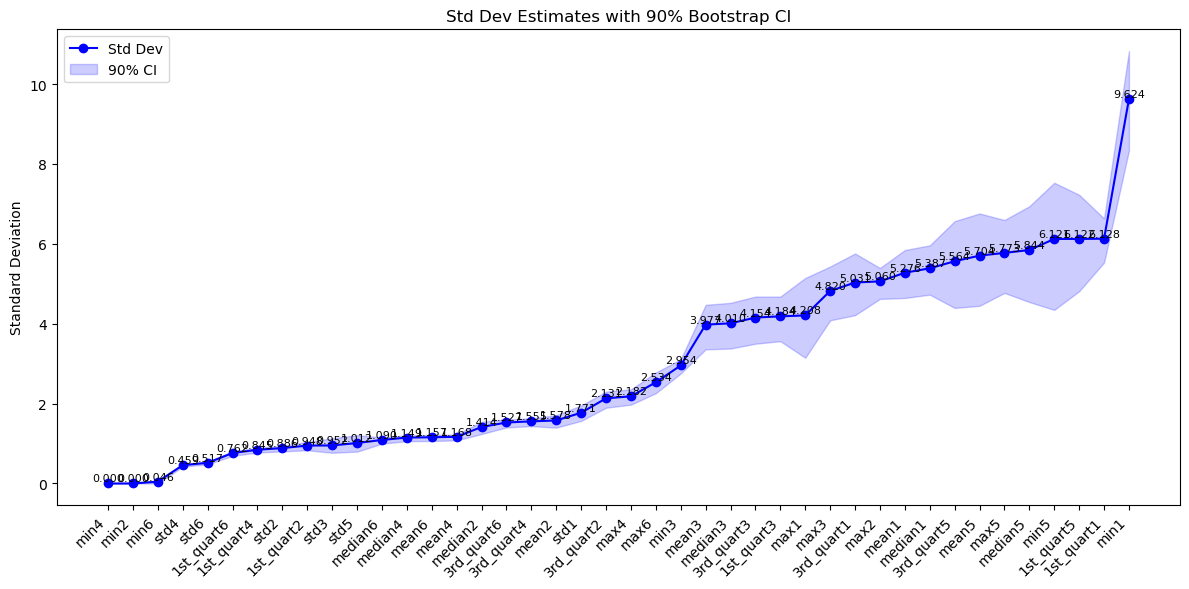

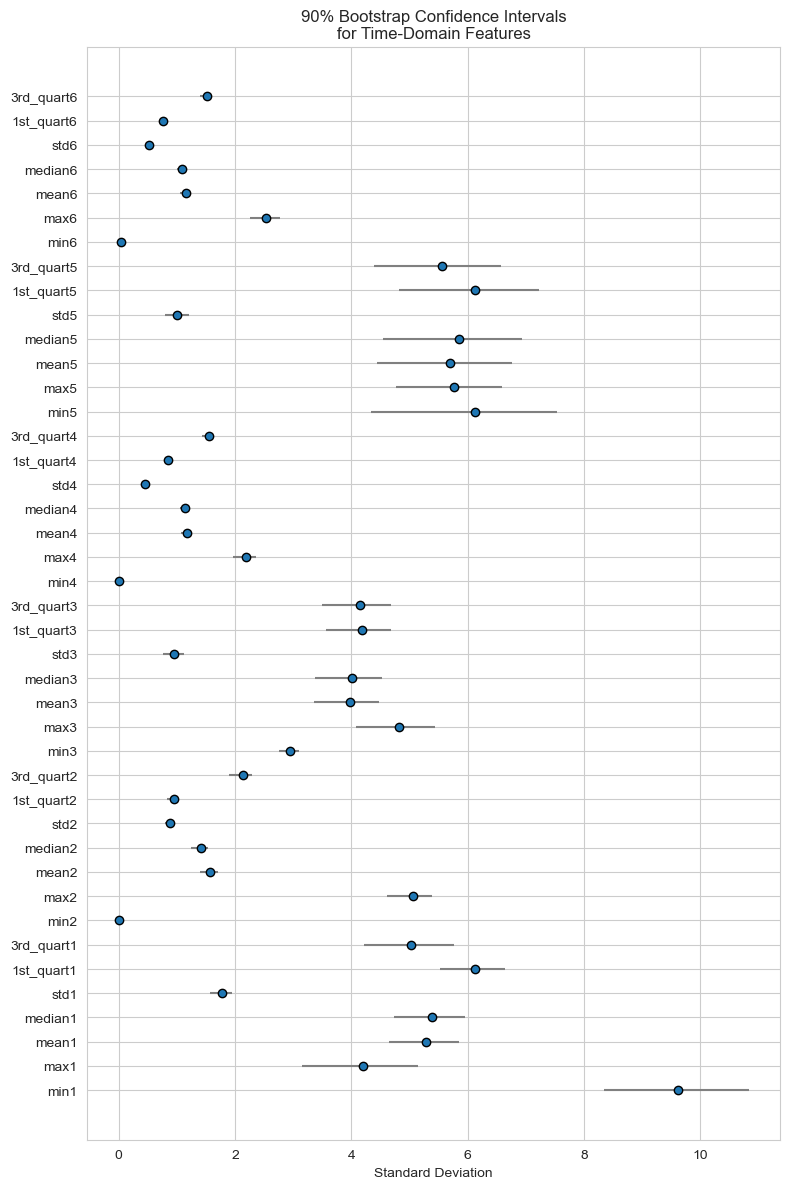

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Step 1: Load the dataset
data_root = Path("..") / "data" / "ARem"
features_df = pd.read_csv(data_root / "time_series_features.csv")

# Step 2: Clean and prepare data
features_df = features_df.copy()
exclude_cols = {"Activity", "activity", "Instance", "instance"}
feature_cols = [col for col in features_df.columns if col not in exclude_cols]

# Ensure all columns are numeric
for col in feature_cols:
    features_df[col] = pd.to_numeric(features_df[col], errors='coerce')

# Step 3: Bootstrap standard deviation + confidence interval
def calculate_std_ci(data, iterations=10000, confidence=0.90, random_state=42):
    rng = np.random.default_rng(random_state)
    n = data.size
    samples = rng.choice(data, size=(iterations, n), replace=True)
    boot_stds = samples.std(axis=1, ddof=1)
    
    low_pct, high_pct = (1 - confidence) / 2 * 100, (1 + confidence) / 2 * 100
    return data.std(ddof=1), (
        np.percentile(boot_stds, low_pct),
        np.percentile(boot_stds, high_pct)
    )

# Step 4: Apply to all features
results = {}
for feat in feature_cols:
    arr = features_df[feat].dropna().to_numpy()
    std, (low, high) = calculate_std_ci(arr)
    results[feat] = {
        "std_dev": std,
        "90%_ci_lower": low,
        "90%_ci_upper": high
    }

df_results = pd.DataFrame(results).T

# Step 5: Summary table
table = df_results.rename(columns={
    "std_dev": "Std Dev",
    "90%_ci_lower": "CI Lower",
    "90%_ci_upper": "CI Upper"
}).round(4)

print("\nStandard Deviations and 90% Bootstrap CIs:\n")
print(table)

# Step 6: Line + ribbon plot
df_plot = table.sort_values("Std Dev")
x = np.arange(len(df_plot))
stds = df_plot["Std Dev"].values
low = df_plot["CI Lower"].values
high = df_plot["CI Upper"].values

plt.figure(figsize=(12, 6))
plt.plot(x, stds, marker="o", linestyle="-", color="blue", label="Std Dev")
plt.fill_between(x, low, high, color="blue", alpha=0.2, label="90% CI")

for xi, y in zip(x, stds):
    plt.text(xi, y, f"{y:.3f}", va="bottom", ha="center", fontsize=8)

plt.xticks(x, df_plot.index, rotation=45, ha="right")
plt.ylabel("Standard Deviation")
plt.title("Std Dev Estimates with 90% Bootstrap CI")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

# Step 7: Horizontal error bar plot
features = df_results.index.tolist()
std_devs = df_results["std_dev"].tolist()
lower_bounds = df_results["90%_ci_lower"].tolist()
upper_bounds = df_results["90%_ci_upper"].tolist()

lower_err = [sd - lb for sd, lb in zip(std_devs, lower_bounds)]
upper_err = [ub - sd for sd, ub in zip(std_devs, upper_bounds)]

plt.figure(figsize=(8, 12))
sns.set_style("whitegrid")
plt.errorbar(
    std_devs,
    features,
    xerr=[lower_err, upper_err],
    fmt='o',
    ecolor='gray',
    markeredgecolor='black'
)
plt.xlabel("Standard Deviation")
plt.title("90% Bootstrap Confidence Intervals\nfor Time-Domain Features")
plt.tight_layout()
plt.show()


### 1] (c) (iv) Use your judgement to select the three most important time-domain features(one option may be min, mean, and max)

I would choose **mean**, **max**, and **standard deviation** as the three most important features. Here's why each feature is significant:

1. **Mean**: The mean represents the average level of activity in the time series data, providing a baseline understanding of the signal's typical magnitude. It's crucial for distinguishing different activities based on their overall intensity.

2. **Max**: Maximum value identifies peak activity or spikes in the signal, effectively capturing outliers and extreme values that could indicate significant events or movements.

3. **Standard Deviation**: Standard deviation measures the variability or spread of the data points around the mean. It's valuable in identifying non-stationary activities such as walking or cycling, where the data fluctuates more widely.

These features together offer a comprehensive view of the signal's behavior, combining measures of central tendency (mean), extreme values (max), and variability (standard deviation). They are well-suited for tasks like classification or anomaly detection due to their ability to capture both the typical and exceptional aspects of the time series data.

- - -

# 2.   **ISLR 3.7.4**

### ***(a) Training RSS when the truth is linear***
#### Because the cubic model includes all the linear terms plus additional $X^2$ and $X^3$ components, it can always fit the training data at least as well as the simple linear model. In practice, this means that - even if the true underlying relationship is purely linear—the training residual sum of squares for the cubic model will be less than or equal to that of the linear model. The extra flexibility simply lets it “sit on top” of the linear fit and possibly mop up some noise, driving the training RSS down.

### ***(b) Test RSS when the truth is linear***
#### When the data truly follow a linear pattern, the linear model strikes the optimal balance between bias and variance. The cubic model’s extra terms are unnecessary and can end up fitting noise instead of signal, which degrades its performance on unseen data. As a result, on a fresh test set you should expect the linear regression to achieve a lower (or at worst equal) RSS compared to the cubic regression, since the simpler model generalizes better in the absence of true curvature.

### ***(c) Training RSS when the truth is nonlinear***
#### Since the cubic regression model is more flexible than the linear model, it includes the linear model as a special case (when coefficients for the quadratic and cubic terms are zero). This means that the cubic model can always fit the training data at least as well as the linear model, and often better if the true relationship is nonlinear. Therefore, regardless of how far the true relationship deviates from linearity, the training RSS of the cubic regression will always be less than or equal to that of the linear model.

#### We would expect the cubic regression model to have a lower training RSS than the linear model, because adding polynomial terms increases the model's capacity to reduce residual errors on the training set. This is a fundamental property of least-squares regression: increasing model complexity cannot increase training RSS.

### ***(d) Test RSS when the truth is nonlinear***
#### On new data, the outcome hinges on the trade-off between capturing true signal and over-fitting noise. If the nonlinearity is strong relative to the noise level, the cubic model will likely generalize better and yield a lower test RSS. But if the additional flexibility simply chases random fluctuations, the linear model may outperform it. Without precise knowledge of how pronounced the nonlinearity is versus the measurement error, we cannot definitively predict which model will achieve the smaller test RSS.


- - -

# Reference
### 1) https://docs.python.org/3/library/shutil.html
### 2) https://scikit-learn.org/stable/modules/generated/sklearn.utils.resample.html https://pandas.pydata.org/pandas-docs/stable/
### 3) https://pandas.pydata.org/pandas-docs/stable/